<a href="https://colab.research.google.com/github/Harold-dev-code/TelecomX_Parte2_Tercer-Challenge/blob/main/TelecomX_Parte2_Tercer_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$\huge \text{🤖 challenge_Telecom-X (Parte 2: Machine Learning)}$$



Nota: Este proyecto es la continuación directa del análisis exploratorio. Puedes ver la Fase 1 (EDA,Limpieza y transformación de datos) aquí: https://github.com/Harold-dev-code/challenge_Telecom-X_parte_uno



<h2>Proyecto de análisis predictivo orientado a la retención de clientes. Implementación de modelos de clasificación en Python para identificar factores críticos que influyen en la cancelación de servicios de Telecom X.</h2>

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#📥 Extracción

In [140]:
df=pd.read_csv('/content/datos_telecomX_procesados.csv')

In [141]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## 🔍👀🔎 Revisión - Verificación

###sabemos que ya nuestro dateset esta tratado anteriormente , pero vamos a preparlos para adecuarlo para el proceso de machine learning

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   objec

### Observamos que el tipo de dato en customer.seniorCitizaen es int64 pero es una variable binaria que indica si el cliente es una persona mayor (1) o no (0)el modelo lo interpretará correctamente como una variable binaria. No necesito cambiarle el tipo de dato.

###Para customer.tenure que tambien es Tipo int64, esta es una variable numérica continua (meses de antigüedad). Aquí depende el modelo predictivo que vamos a elejir:

Si usamos **Regresión Logística:** Aplicaremos un escalado (como StandardScaler). Como tenure puede ir de 0 a 72 meses y otras variables solo son 0 o 1, el modelo podría pensar que la antigüedad es "más importante" solo porque el número es más grande.

Si usamos **Random Forest:** No necesitamos hacer nada. Este modelo no se ve afectado por la diferencia de escalas entre meses y valores binarios.

### Charges.Monthly y Charges.Total: Ambos están como float64, listos para cálculos matemáticos.

### Variables object: Tenemos 17 columnas no númericas(como gender, Partner, Dependents, etc.). Estas sí necesitan ser transformadas a números (usando One-Hot Encoding o Label Encoding) antes de entrenar cualquier modelo o descartarlas las variables que no son necesarias para influir en la cancelación de servicios de Telecom X.

In [143]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

#🗑 Eliminación de Columnas Irrelevantes

### Quitamos el customerID que es el id del cliente. esta no posee una característica predictiva

> Agregar bloque entrecomillado



In [144]:
df = df.drop('customerID', axis=1)

In [145]:
df.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7043 non-null   object 
 1   customer.gender            7043 non-null   object 
 2   customer.SeniorCitizen     7043 non-null   int64  
 3   customer.Partner           7043 non-null   object 
 4   customer.Dependents        7043 non-null   object 
 5   customer.tenure            7043 non-null   int64  
 6   phone.PhoneService         7043 non-null   object 
 7   phone.MultipleLines        7043 non-null   object 
 8   internet.InternetService   7043 non-null   object 
 9   internet.OnlineSecurity    7043 non-null   object 
 10  internet.OnlineBackup      7043 non-null   object 
 11  internet.DeviceProtection  7043 non-null   object 
 12  internet.TechSupport       7043 non-null   object 
 13  internet.StreamingTV       7043 non-null   objec

# 💻 Encoding

###Antes de comenzar a transformar en binario las variables categóricas,  análizamos que variables tiene más de 2 valores unicos

In [147]:
print("Columnas categóricas con más de 2 valores únicos: ")

# Seleccionar solo las columnas de tipo 'object' del DataFrame original (antes del encoding)
categorical_cols_original = df.select_dtypes(include='object').columns.tolist()

# vamos a mirar las columnas originales (object) de df y verificar si tienen más de 2 valores únicos
for col in categorical_cols_original:
    unique_values_count = df[col].nunique()
    if unique_values_count > 2:
        print(f"- Columna '{col}': {unique_values_count} valores únicos")
        print(f"  Valores únicos: {df[col].unique()}")


Columnas categóricas con más de 2 valores únicos: 
- Columna 'phone.MultipleLines': 3 valores únicos
  Valores únicos: ['No' 'Yes' 'No phone service']
- Columna 'internet.InternetService': 3 valores únicos
  Valores únicos: ['DSL' 'Fiber optic' 'No']
- Columna 'internet.OnlineSecurity': 3 valores únicos
  Valores únicos: ['No' 'Yes' 'No internet service']
- Columna 'internet.OnlineBackup': 3 valores únicos
  Valores únicos: ['Yes' 'No' 'No internet service']
- Columna 'internet.DeviceProtection': 3 valores únicos
  Valores únicos: ['No' 'Yes' 'No internet service']
- Columna 'internet.TechSupport': 3 valores únicos
  Valores únicos: ['Yes' 'No' 'No internet service']
- Columna 'internet.StreamingTV': 3 valores únicos
  Valores únicos: ['Yes' 'No' 'No internet service']
- Columna 'internet.StreamingMovies': 3 valores únicos
  Valores únicos: ['No' 'Yes' 'No internet service']
- Columna 'account.Contract': 3 valores únicos
  Valores únicos: ['One year' 'Month-to-month' 'Two year']
- Colu

### Observamos que varias variables de servicio de internet contiene un tercer valor llamado 'No internet service'. No tiene sentido que un cliente que no tiene internet tenga 'seguridad en línea', backup en línea, streming...y otros servicios que necesitan internet por lo que 'No internet service' es funcionalmente lo mismo que 'No' para esas características específicas.

In [148]:
print("\nColumnas que contienen 'No internet service' en sus registros (en el DataFrame original 'df'):")
for col in df.columns:
    if df[col].dtype == 'object': # Solo revisamos columnas de texto
        if 'No internet service' in df[col].unique():
            print(f"- Columna '{col}' contiene 'No internet service'.")



Columnas que contienen 'No internet service' en sus registros (en el DataFrame original 'df'):
- Columna 'internet.OnlineSecurity' contiene 'No internet service'.
- Columna 'internet.OnlineBackup' contiene 'No internet service'.
- Columna 'internet.DeviceProtection' contiene 'No internet service'.
- Columna 'internet.TechSupport' contiene 'No internet service'.
- Columna 'internet.StreamingTV' contiene 'No internet service'.
- Columna 'internet.StreamingMovies' contiene 'No internet service'.


###Ya tenemos identificadas las variables con 'No internet service', también observe que la variable o columna  **phone.MultipleLines** tiene un valor similar 'No phone service' y se le puede aplicar la misma lógica: Si un cliente no tiene servicio telefónico (phone.PhoneService es 'No'), entonces lógicamente no puede tener 'múltiples líneas'. Por lo tanto, el valor 'No phone service' en la columna phone.MultipleLines es funcionalmente equivalente a 'No' (es decir, no tiene múltiples líneas porque no tiene ni siquiera una línea principal).

In [149]:
#verificamos
df[df['phone.MultipleLines'] == 'No phone service'].sample(10)

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
1903,No,Female,0,No,No,36,No,No phone service,DSL,Yes,Yes,Yes,Yes,No,Yes,Two year,Yes,Mailed check,53.10,1901.25
2225,No,Male,0,Yes,No,70,No,No phone service,DSL,No,Yes,Yes,Yes,No,Yes,One year,Yes,Bank transfer (automatic),51.05,3635.15
3654,Yes,Male,1,No,No,4,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),25.20,102.50
5011,No,Female,0,No,No,37,No,No phone service,DSL,No,No,Yes,No,No,Yes,Month-to-month,Yes,Credit card (automatic),40.20,1478.85
6492,Yes,Male,0,Yes,No,13,No,No phone service,DSL,Yes,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,54.45,706.85
5035,No,Female,0,Yes,Yes,32,No,No phone service,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,35.15,1051.05
4429,No,Female,0,No,No,23,No,No phone service,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.95,996.85
5241,No,Female,0,Yes,Yes,2,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,30.25,63.75
5702,Yes,Male,0,Yes,No,40,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,One year,Yes,Electronic check,42.35,1716.45
1709,Yes,Female,0,Yes,No,2,No,No phone service,DSL,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,35.10,68.75


###Ya identificadas las varibles categóricas que podemos simplificar procedemos, primero a simplificar y despues hacer el encoding a las variables

In [150]:
df_encoded = df.copy()

# Identificar las columnas de servicios de internet que contienen 'No internet service'
internet_service_cols = [
    'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport',
    'internet.StreamingTV', 'internet.StreamingMovies'
]

# Reemplazar 'No internet service' con 'No' en estas columnas específicas
for col in internet_service_cols:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].replace('No internet service', 'No')

# Reemplazar 'No phone service' con 'No' en la columna 'phone.MultipleLines'
if 'phone.MultipleLines' in df_encoded.columns:
    df_encoded['phone.MultipleLines'] = df_encoded['phone.MultipleLines'].replace('No phone service', 'No')

# Identificar columnas de tipo 'object' que no sean la variable objetivo 'Churn'
categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

# Aplicar One-Hot Encoding a las columnas categóricas
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=False)

# Para la variable objetivo 'Churn', convertir a binario (0 y 1)
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})



print("\nInformación del DataFrame después del One-Hot Encoding:\n")
df_encoded.info()
print("---------------------------------------------------------------------------------------")
print("---------------------------------------------------------------------------------------")

df_encoded


Información del DataFrame después del One-Hot Encoding:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Churn                                            7043 non-null   int64  
 1   customer.SeniorCitizen                           7043 non-null   int64  
 2   customer.tenure                                  7043 non-null   int64  
 3   account.Charges.Monthly                          7043 non-null   float64
 4   account.Charges.Total                            7043 non-null   float64
 5   customer.gender_Female                           7043 non-null   bool   
 6   customer.gender_Male                             7043 non-null   bool   
 7   customer.Partner_No                              7043 non-null   bool   
 8   customer.Partner_Yes                             7

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,customer.gender_Female,customer.gender_Male,customer.Partner_No,customer.Partner_Yes,customer.Dependents_No,...,internet.StreamingMovies_Yes,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_No,account.PaperlessBilling_Yes,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.60,593.30,True,False,False,True,False,...,False,False,True,False,False,True,False,False,False,True
1,0,0,9,59.90,542.40,False,True,True,False,True,...,True,True,False,False,True,False,False,False,False,True
2,1,0,4,73.90,280.85,False,True,True,False,True,...,False,True,False,False,False,True,False,False,True,False
3,1,1,13,98.00,1237.85,False,True,False,True,True,...,True,True,False,False,False,True,False,False,True,False
4,1,1,3,83.90,267.40,True,False,False,True,True,...,False,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,13,55.15,742.90,True,False,True,False,True,...,False,False,True,False,True,False,False,False,False,True
7039,1,0,22,85.10,1873.70,False,True,False,True,True,...,True,True,False,False,False,True,False,False,True,False
7040,0,0,2,50.30,92.75,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
7041,0,0,67,67.85,4627.65,False,True,False,True,False,...,True,False,False,True,True,False,False,False,False,True


#🔍📉Verificación de la Proporción de Cancelación (Churn)

In [151]:
# Calcular la proporción de clientes que cancelaron (Churn=1) vs. activos (Churn=0)
churn_counts = df_encoded['Churn'].value_counts()
churn_proportions = df_encoded['Churn'].value_counts(normalize=True) * 100

print("Distribución de la variable 'Churn':\n")
print("Conteo absoluto:")
print(churn_counts)
print("\nProporción (%):")
print(churn_proportions)



Distribución de la variable 'Churn':

Conteo absoluto:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporción (%):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


##Observación: Existe un desbalance significativo en las clases. La clase minoritaria (Churn=1) representa menos del 30% del total.
Esto es común en problemas de predicción de churn. Se deberán considerar técnicas de manejo de desbalance (e.g., sobremuestreo, submuestreo, SMOTE, ajuste de pesos de clase) al entrenar los modelos predictivos para evitar que el modelo ignore la clase minoritaria.

#⚖️ Balanceo de Clases

## 📊 Separación de Datos para el Modelado

In [152]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve


# Separar características (X) y variable objetivo (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usamos stratify=y para asegurar que la proporción de clases sea similar en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print("\nDistribución de la clase 'Churn' en y_train antes de SMOTE:")
print(y_train.value_counts(normalize=True) * 100)

# Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote_unscaled, y_train_smote_unscaled = smote.fit_resample(X_train, y_train)

print("\nDistribución de la clase 'Churn' en y_train después de SMOTE:")
print(y_train_smote_unscaled.value_counts(normalize=True) * 100)


Dimensiones de X_train: (4930, 38)
Dimensiones de y_train: (4930,)
Dimensiones de X_test: (2113, 38)
Dimensiones de y_test: (2113,)

Distribución de la clase 'Churn' en y_train antes de SMOTE:
Churn
0    73.46856
1    26.53144
Name: proportion, dtype: float64

Distribución de la clase 'Churn' en y_train después de SMOTE:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


## ⚙️ Entrenamiento del Modelo: Regresión Logística (Baseline)

In [153]:
# Inicializar y entrenar el modelo de Regresión Logística
model_unscaled = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model_unscaled.fit(X_train_smote_unscaled, y_train_smote_unscaled)

print("Modelo de Regresión Logística entrenado correctamente ")


Modelo de Regresión Logística entrenado correctamente 


## 📈 Evaluación del Modelo


Accuracy del modelo : 0.7766209181258874

Reporte de Clasificación :
               precision    recall  f1-score   support

           0       0.86      0.83      0.85      1552
           1       0.57      0.62      0.60       561

    accuracy                           0.78      2113
   macro avg       0.72      0.73      0.72      2113
weighted avg       0.78      0.78      0.78      2113


Área bajo la curva ROC (AUC-ROC): 0.830574544719481


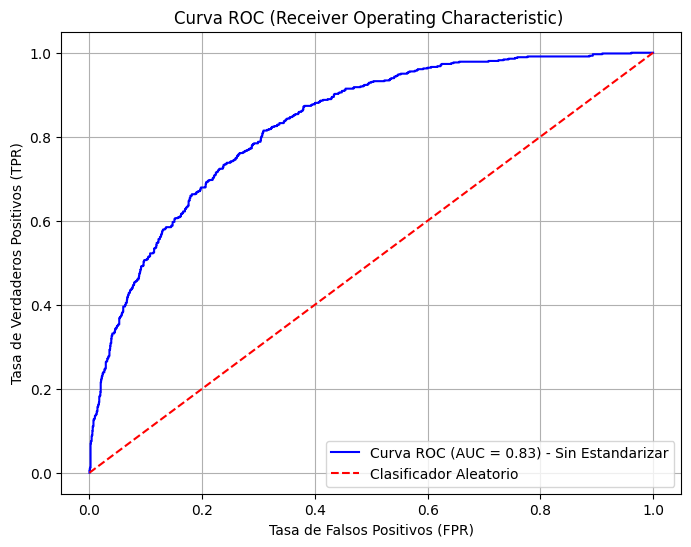

In [154]:
# Predicciones en el conjunto de prueba
y_pred_unscaled = model_unscaled.predict(X_test)
y_pred_proba_unscaled = model_unscaled.predict_proba(X_test)[:, 1] # Probabilidades de la clase positiva (Churn=1)

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo :", accuracy_score(y_test, y_pred_unscaled))
print("\nReporte de Clasificación :\n", classification_report(y_test, y_pred_unscaled))
print("\nÁrea bajo la curva ROC (AUC-ROC):", roc_auc_score(y_test, y_pred_proba_unscaled))

# Curva ROC
fpr_unscaled, tpr_unscaled, thresholds_unscaled = roc_curve(y_test, y_pred_proba_unscaled)
plt.figure(figsize=(8, 6))
plt.plot(fpr_unscaled, tpr_unscaled, color='blue', label=f'Curva ROC (AUC = {roc_auc_score(y_test, y_pred_proba_unscaled):.2f}) - Sin Estandarizar')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) ')
plt.legend()
plt.grid(True)
plt.show()


###El modelo de Regresión Logística, combinado con SMOTE para manejar el desbalance, es un buen punto de partida y muestra un prometedor poder discriminatorio (según el AUC). Sin embargo, su rendimiento en la identificación de la clase minoritaria (Churn=1) es moderado.

# ✨ Estandarización de Datos para el Modelo Escalado

In [155]:
from sklearn.preprocessing import StandardScaler

# Crear copias de los conjuntos de entrenamiento y prueba para la estandarización
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
y_train_scaled = y_train.copy() # y_train no necesita estandarización, pero la renombramos para coherencia
y_test_scaled = y_test.copy() # y_test no necesita estandarización, pero la renombramos para coherencia

# Identificar columnas numéricas para estandarizar (excluyendo las booleanas generadas por One-Hot Encoding)
numerical_cols = X_train_scaled.select_dtypes(include=['int64', 'float64']).columns

# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar el scaler solo con los datos de entrenamiento y transformar ambos conjuntos
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_scaled[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_scaled[numerical_cols])

print("\nDatos numéricos estandarizados.")

# Aplicar SMOTE al conjunto de entrenamiento estandarizado
smote_scaled = SMOTE(random_state=42)
X_train_smote_scaled, y_train_smote_scaled = smote_scaled.fit_resample(X_train_scaled, y_train_scaled)

print("\nDistribución de la clase 'Churn' en y_train después de SMOTE (con datos estandarizados):")
print(y_train_smote_scaled.value_counts(normalize=True) * 100)



Datos numéricos estandarizados.

Distribución de la clase 'Churn' en y_train después de SMOTE (con datos estandarizados):
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


## ⚙️ Entrenamiento del Modelo: Regresión Logística (con datos Estandarizados)

In [156]:
# Inicializar y entrenar el modelo de Regresión Logística con datos estandarizados
model_scaled = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model_scaled.fit(X_train_smote_scaled, y_train_smote_scaled)

print("Modelo de Regresión Logística entrenado correctamente con datos estandarizados.")


Modelo de Regresión Logística entrenado correctamente con datos estandarizados.


## 📈 Evaluación del Modelo (con datos Estandarizados)


Accuracy del modelo con datos estandarizados: 0.779460482725982

Reporte de Clasificación (con datos estandarizados):
               precision    recall  f1-score   support

           0       0.88      0.81      0.84      1552
           1       0.57      0.69      0.62       561

    accuracy                           0.78      2113
   macro avg       0.72      0.75      0.73      2113
weighted avg       0.80      0.78      0.79      2113


Área bajo la curva ROC (AUC-ROC) con datos estandarizados: 0.8365090412922433


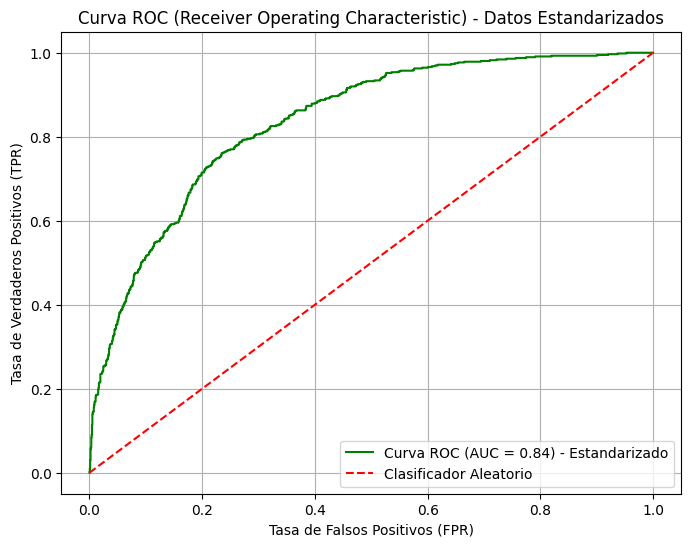

In [157]:
# Predicciones en el conjunto de prueba (que ya está estandarizado)
y_pred_scaled = model_scaled.predict(X_test_scaled)
y_pred_proba_scaled = model_scaled.predict_proba(X_test_scaled)[:, 1] # Probabilidades de la clase positiva (Churn=1)

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo con datos estandarizados:", accuracy_score(y_test_scaled, y_pred_scaled))
print("\nReporte de Clasificación (con datos estandarizados):\n", classification_report(y_test_scaled, y_pred_scaled))
print("\nÁrea bajo la curva ROC (AUC-ROC) con datos estandarizados:", roc_auc_score(y_test_scaled, y_pred_proba_scaled))

# Curva ROC
fpr_scaled, tpr_scaled, thresholds_scaled = roc_curve(y_test_scaled, y_pred_proba_scaled)
plt.figure(figsize=(8, 6))
plt.plot(fpr_scaled, tpr_scaled, color='green', label=f'Curva ROC (AUC = {roc_auc_score(y_test_scaled, y_pred_proba_scaled):.2f}) - Estandarizado')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) - Datos Estandarizados')
plt.legend()
plt.grid(True)
plt.show()


## 📊 Comparación de Modelos: Sin Estandarizar vs. Estandarizado

Al comparar los resultados de la Regresión Logística con datos **sin estandarizar** y **estandarizados**, observamos una leve mejora general, especialmente relevante para nuestro objetivo de predecir el Churn.

### **Resultados Clave:**

| Métrica             | Modelo Sin Estandarizar | Modelo Estandarizado | Comentario                                                                      |
| :------------------ | :---------------------- | :------------------- | :------------------------------------------------------------------------------ |
| **Accuracy**        | 0.7766                  | 0.7795               | Ligera mejora general, pero la Accuracy puede ser engañosa en datos desbalanceados. |
| **Precision (Churn=1)** | 0.57                    | 0.57                 | Se mantuvo igual. De cada 100 clientes predichos como Churn, 57 realmente lo fueron. |
| **Recall (Churn=1)**    | 0.62                    | **0.69**             | **Mejora significativa.** El modelo estandarizado detecta el 69% de los clientes que realmente cancelan, frente al 62% del modelo sin estandarizar. |
| **F1-Score (Churn=1)**  | 0.60                    | **0.62**             | Refleja la mejora en el Recall, indicando un mejor equilibrio entre Precision y Recall para la clase minoritaria. |
| **AUC-ROC**         | 0.8306                  | **0.8365**           | **Mejora.** El modelo estandarizado tiene una mejor capacidad general para discriminar entre las clases de Churn y No-Churn. |

### **Conclusión de la Comparación:**

La **estandarización de las características numéricas ha demostrado ser beneficiosa** para el modelo de Regresión Logística en este problema de predicción de Churn.

Aunque la mejora en el `Accuracy` general fue leve, lo más importante es el **aumento notable en el `Recall` y el `AUC-ROC` para la clase minoritaria (Churn=1)**. Esto significa que el modelo estandarizado es significativamente mejor identificando a los clientes que realmente tienen una alta probabilidad de cancelar, lo cual es de gran valor para implementar estrategias de retención más efectivas.

Esta validación refuerza la importancia de aplicar el preprocesamiento adecuado según la sensibilidad de cada algoritmo a la escala de los datos.

## 🌳 Entrenamiento del Modelo: Random Forest

In [158]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar y entrenar el modelo de Random Forest
# Usamos los datos balanceados con SMOTE pero SIN estandarizar, ya que Random Forest no es sensible a la escala.
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote_unscaled, y_train_smote_unscaled)

print("Modelo Random Forest entrenado correctamente.")


Modelo Random Forest entrenado correctamente.


## 📊 Evaluación del Modelo Random Forest


Accuracy del modelo Random Forest: 0.7770941788925698

Reporte de Clasificación (Random Forest):
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1552
           1       0.59      0.51      0.55       561

    accuracy                           0.78      2113
   macro avg       0.71      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113


Área bajo la curva ROC (AUC-ROC) Random Forest: 0.8125918830512524


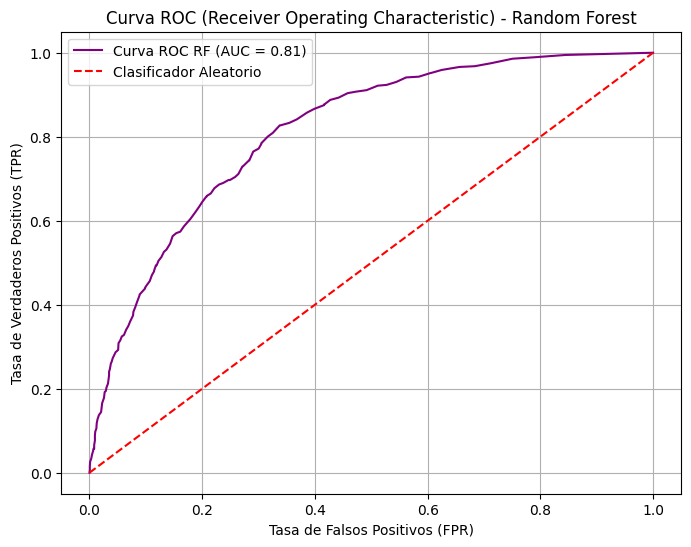

In [159]:
# Predicciones en el conjunto de prueba (no estandarizado)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nReporte de Clasificación (Random Forest):\n", classification_report(y_test, y_pred_rf))
print("\nÁrea bajo la curva ROC (AUC-ROC) Random Forest:", roc_auc_score(y_test, y_pred_proba_rf))

# Curva ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='purple', label=f'Curva ROC RF (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) - Random Forest')
plt.legend()
plt.grid(True)
plt.show()


## 🚀 Entrenamiento del Modelo: XGBoost

In [186]:
from xgboost import XGBClassifier

# Inicializar y entrenar el modelo XGBoost
# Usamos los datos balanceados con SMOTE pero SIN estandarizar.
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_smote_unscaled, y_train_smote_unscaled)

print("Modelo XGBoost entrenado correctamente.")


Modelo XGBoost entrenado correctamente.


## 📊 Evaluación del Modelo XGBoost


Accuracy del modelo XGBoost: 0.7770941788925698

Reporte de Clasificación (XGBoost):
               precision    recall  f1-score   support

           0       0.84      0.86      0.85      1552
           1       0.59      0.54      0.56       561

    accuracy                           0.78      2113
   macro avg       0.71      0.70      0.71      2113
weighted avg       0.77      0.78      0.77      2113


Área bajo la curva ROC (AUC-ROC) XGBoost: 0.8126705579138872


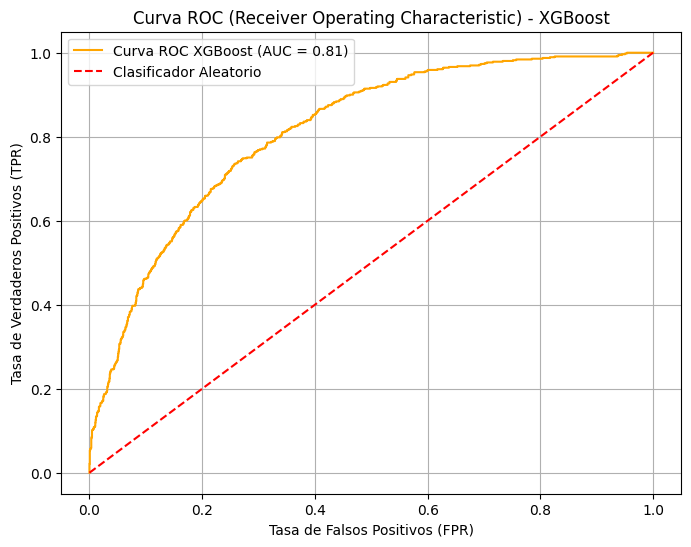

In [161]:
# Predicciones en el conjunto de prueba (no estandarizado)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("\nReporte de Clasificación (XGBoost):\n", classification_report(y_test, y_pred_xgb))
print("\nÁrea bajo la curva ROC (AUC-ROC) XGBoost:", roc_auc_score(y_test, y_pred_proba_xgb))

# Curva ROC
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='orange', label=f'Curva ROC XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) - XGBoost')
plt.legend()
plt.grid(True)
plt.show()


## 📊 Comparación de Modelos: Regresión Logística vs. Random Forest y XGBoost


### **Resultados Clave de los Modelos:**

| Métrica             | Regresión Logística (Estandarizado) | Random Forest           | XGBoost                 |
| :------------------ | :---------------------------------- | :---------------------- | :---------------------- |
| **Accuracy**        | 0.7795                              | 0.7771                  | 0.7771                  |
| **Precision (Churn=1)** | 0.57                                | **0.59**                | **0.59**                |
| **Recall (Churn=1)**    | **0.69**                            | 0.51                    | 0.54                    |
| **F1-Score (Churn=1)**  | **0.62**                            | 0.55                    | 0.56                    |
| **AUC-ROC**         | **0.8365**                          | 0.8126                  | 0.8127                  |

### **Conclusión de la Comparación:**

*   **Accuracy General**: Todos los modelos muestran una `Accuracy` muy similar, alrededor del 77-78%.
*   **Rendimiento en la Clase Minoritaria (Churn=1)**:
    *   El **Random Forest** y **XGBoost** mostraron una ligera mejora en la `Precision` (0.59) comparado con la Regresión Logística (0.57).
    *   Sin embargo, el **`Recall` de los modelos de árbol para la clase 'Churn' es notablemente más bajo (0.51 y 0.54)** que el del modelo estandarizado de Regresión Logística (0.69). Esto significa que los modelos basados en árboles actuales son menos efectivos para identificar a los clientes que realmente cancelan.
    *   El `F1-Score` de los modelos de árbol (0.55 y 0.56) también es inferior al del modelo estandarizado de Regresión Logística (0.62), lo que indica un peor equilibrio entre `Precision` y `Recall` para la clase crítica.
*   **Capacidad Discriminatoria (AUC-ROC)**: Los modelos de árbol tienen el AUC-ROC más bajo (0.8126 y 0.8127). Esto sugiere que su capacidad general para diferenciar entre clientes que van a cancelar y los que no es inferior a la de la Regresión Logística estandarizada (0.8365).

**En este análisis, el modelo de Regresión Logística con datos estandarizados (`model_scaled`) sigue siendo el que presenta el mejor rendimiento general**, destacándose por su mayor `Recall` y `AUC-ROC` en la detección de la cancelación de clientes, que es el objetivo principal de nuestro análisis.

#🎯Correlación y Selección de Variables

Correlación de las variables numéricas con 'Churn':
 account.Charges.Monthly    0.193356
customer.SeniorCitizen     0.150889
account.Charges.Total     -0.198324
customer.tenure           -0.352229
Name: Churn, dtype: float64


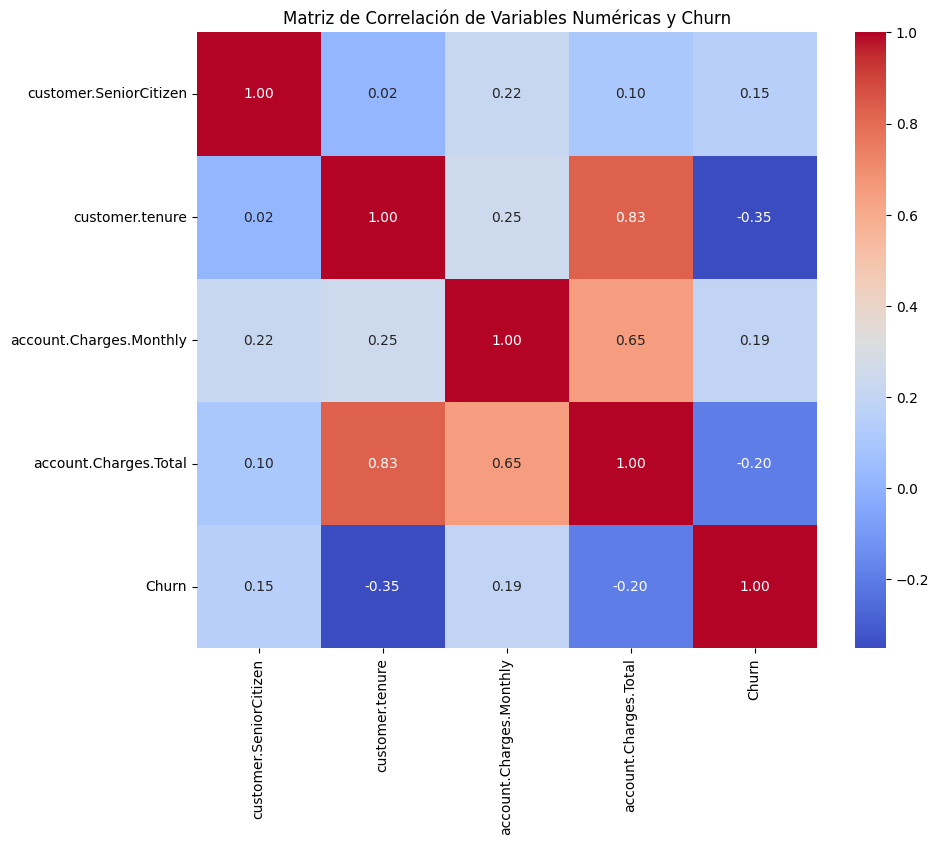

In [162]:
# Identificar las columnas numéricas relevantes (int64 y float64) del df_encoded original
# Excluimos las columnas booleanas generadas por One-Hot Encoding para esta visualización específica
numerical_features = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Asegurarse de que 'Churn' esté en la lista si no es ya un int64 o float64, y luego eliminarla para calcular correlaciones solo entre features
if 'Churn' in numerical_features:
    numerical_features.remove('Churn')

# Incluir 'Churn' para la matriz de correlación final que queremos visualizar
features_for_correlation = numerical_features + ['Churn']

# Calcular la matriz de correlación solo para estas características
correlation_matrix_numeric = df_encoded[features_for_correlation].corr()

# Filtrar la correlación de estas características con 'Churn' y ordenarlas
churn_correlation_numeric = correlation_matrix_numeric['Churn'].drop('Churn').sort_values(ascending=False)
print("Correlación de las variables numéricas con 'Churn':\n", churn_correlation_numeric)

# Visualizar la matriz de correlación de las variables numéricas y 'Churn'
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_numeric, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas y Churn')
plt.show()


## === CORRELACIÓN DE VARIABLES NUMÉRICAS CON 'CHURN' ===

### 1. customer.tenure (-0.3522): Correlación negativa moderada.
####    Es el predictor más importante: a menor antigüedad, más probabilidad de churn.

### 2. account.Charges.Total (-0.1983): Correlación negativa débil.
###   Clientes con menor gasto acumulado (generalmente nuevos) tienen mayor tendencia a irse.

### 3. account.Charges.Monthly (0.1934): Correlación positiva débil.
####   Sugiere que cargos mensuales elevados incrementan ligeramente la cancelación.

### 4. customer.SeniorCitizen (0.1509): Correlación positiva débil.
####   Indica que el segmento de ciudadanos de la tercera edad tiene mayor riesgo de churn.

## === CORRELACIÓN DE VARIABLES NUMÉRICAS ENTRE ELLAS=

###Cuando dos o más variables predictoras en un modelo están altamente correlacionadas entre sí, estamos ante un problema conocido como multicolinealidad.
### La correlación entre customer.tenure y account.Charges.Total es de 0.83, lo cual es bastante alto.



###Esta visualización confirma que las características numéricas elegidas son relevantes y que nuestro modelo de Regresión Logística las está utilizando de manera significativa, especialmente customer.tenure y account.Charges.Total
###Pero como entre ellas tambien ay una fuerte correlación, obtamos por eliminar una de ellas y escogemos la de menor correlación con churn y es account.Charges.Total que tiene una correlación de -0.20 .

#🗑 Eliminación de Columnas

In [163]:
df_encoded= df_encoded.drop('account.Charges.Total', axis=1)

###  buscamos varibles categóricas con menor correlacion con Churn

In [164]:
print('--- Variables con menor correlación absoluta con Churn ---\n')

# Excluir la columna 'Churn' de las características para calcular la correlación
features = df_encoded.drop('Churn', axis=1)

# Calcular la correlación absoluta de todas las características con 'Churn' usando df_encoded['Churn']
correlations_with_churn = features.corrwith(df_encoded['Churn']).abs()

# Ordenar las correlaciones de menor a mayor para encontrar las más débiles
weakest_correlations = correlations_with_churn.sort_values(ascending=True)

# Mostrar las 5 variables con la menor correlación absoluta
print(weakest_correlations.head(5))

--- Variables con menor correlación absoluta con Churn ---

customer.gender_Female     0.008612
customer.gender_Male       0.008612
phone.PhoneService_No      0.011942
phone.PhoneService_Yes     0.011942
phone.MultipleLines_Yes    0.040102
dtype: float64


In [165]:
df_encoded = df_encoded.drop(columns=['customer.gender_Male', 'customer.gender_Female', 'phone.PhoneService_No', 'phone.PhoneService_Yes'], errors='ignore')

#Análisis Dirigido

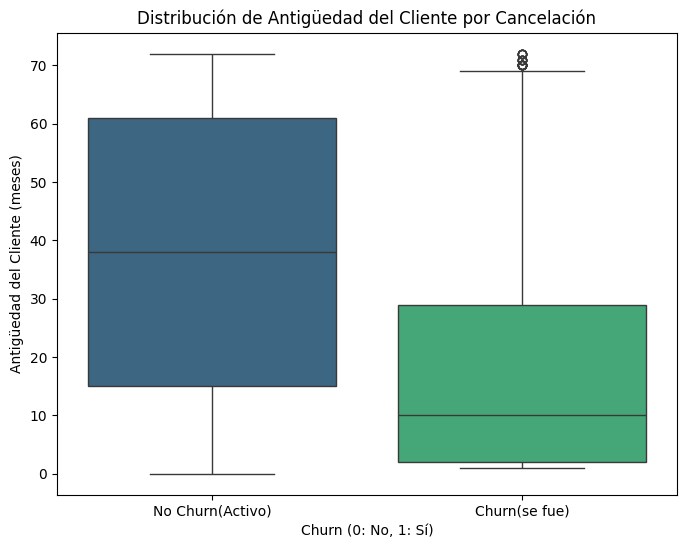


Antigüedad media por estado de Cancelación:
 Churn
0    37.569965
1    17.979133
Name: customer.tenure, dtype: float64


In [166]:
# Boxplot de Antigüedad del cliente (customer.tenure) vs. Cancelación (Churn)
# Usamos el df_encoded ya que 'Churn' está en formato 0/1 y 'customer.tenure' es numérica.
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_encoded, x='Churn', y='customer.tenure', hue='Churn', palette='viridis', legend=False)
plt.title('Distribución de Antigüedad del Cliente por Cancelación')
plt.xlabel('Churn (0: No, 1: Sí)')
plt.ylabel('Antigüedad del Cliente (meses)')
plt.xticks(ticks=[0, 1], labels=['No Churn(Activo)', 'Churn(se fue)'])
plt.show()

# Para una mejor interpretación, calculamos las medias de antigüedad por grupo de Churn
tenure_by_churn = df_encoded.groupby('Churn')['customer.tenure'].mean()
print("\nAntigüedad media por estado de Cancelación:\n", tenure_by_churn)


###Claramente se observa que la caja (que representa el 50% central de los datos) para los clientes que cancelaron está ubicada en valores de antigüedad mucho más bajos. La antigüedad media (indicada por la línea dentro de la caja) y la distribución general para los churners se concentran en los primeros meses de servicio. En contraste, los clientes activos tienen una distribución de antigüedad mucho más extendida y con valores promedio y medianos significativamente más altos.

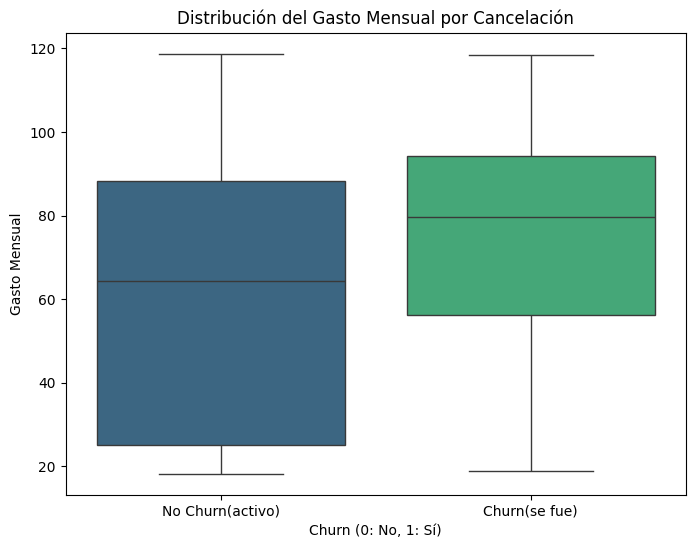


Gasto Mensual medio por estado de Cancelación:
 Churn
0    61.265124
1    74.441332
Name: account.Charges.Monthly, dtype: float64


In [167]:
# Boxplot de Gasto total (account.Charges.Total) vs. Cancelación (Churn)
# Usamos el df_encoded ya que 'Churn' está en formato 0/1 y 'account.Charges.Total' es numérica.
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_encoded, x='Churn', y='account.Charges.Monthly', hue='Churn', palette='viridis', legend=False)
plt.title('Distribución del Gasto Mensual por Cancelación')
plt.xlabel('Churn (0: No, 1: Sí)')
plt.ylabel('Gasto Mensual')
plt.xticks(ticks=[0, 1], labels=['No Churn(activo)', 'Churn(se fue)'])
plt.show()

# Para una mejor interpretación, calculamos las medias de gasto mensual por grupo de Churn
charges_monthly_by_churn = df_encoded.groupby('Churn')['account.Charges.Monthly'].mean()
print("\nGasto Mensual medio por estado de Cancelación:\n", charges_monthly_by_churn)


###El boxplot y las medias confirman que los clientes que cancelaron (Churn=1) tienen un gasto mensual medio más alto (aproximadamente 74.44) en comparación con los clientes activos (Churn=0) (aproximadamente 61.26). Esto sugiere que un cargo mensual elevado podría ser un factor que contribuye a la decisión de un cliente de cancelar el servicio.

## ✨ Re-entrenamiento y Evaluación del Modelo de Regresión Logística (con Variables Eliminadas)

In [168]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separar características (X) y variable objetivo (y) del df_encoded actualizado
X_new = df_encoded.drop('Churn', axis=1)
y_new = df_encoded['Churn']

# 2. Dividir los datos en conjuntos de entrenamiento y prueba
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42, stratify=y_new)

print(f"Dimensiones de X_train_new: {X_train_new.shape}")
print(f"Dimensiones de y_train_new: {y_train_new.shape}")
print(f"Dimensiones de X_test_new: {X_test_new.shape}")
print(f"Dimensiones de y_test_new: {y_test_new.shape}")

# 3. Estandarización de datos numéricos
# Identificar columnas numéricas para estandarizar
numerical_cols_new = X_train_new.select_dtypes(include=['int64', 'float64']).columns

# Inicializar el StandardScaler
scaler_new = StandardScaler()

# Crear copias para estandarización
X_train_scaled_new = X_train_new.copy()
X_test_scaled_new = X_test_new.copy()

X_train_scaled_new[numerical_cols_new] = scaler_new.fit_transform(X_train_scaled_new[numerical_cols_new])
X_test_scaled_new[numerical_cols_new] = scaler_new.transform(X_test_scaled_new[numerical_cols_new])

print("\nDatos numéricos estandarizados para el nuevo modelo.")

# 4. Aplicar SMOTE al conjunto de entrenamiento estandarizado
smote_new = SMOTE(random_state=42)
X_train_smote_scaled_new, y_train_smote_scaled_new = smote_new.fit_resample(X_train_scaled_new, y_train_new)

print("\nDistribución de la clase 'Churn' en y_train después de SMOTE (datos estandarizados y nuevos):")
print(y_train_smote_scaled_new.value_counts(normalize=True) * 100)

Dimensiones de X_train_new: (4930, 33)
Dimensiones de y_train_new: (4930,)
Dimensiones de X_test_new: (2113, 33)
Dimensiones de y_test_new: (2113,)

Datos numéricos estandarizados para el nuevo modelo.

Distribución de la clase 'Churn' en y_train después de SMOTE (datos estandarizados y nuevos):
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


### ⚙️ Entrenamiento del Modelo de Regresión Logística (con datos Estandarizados y Variables Reducidas)

In [169]:
# Inicializar y entrenar el modelo de Regresión Logística con datos estandarizados y balanceados
model_scaled_new = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model_scaled_new.fit(X_train_smote_scaled_new, y_train_smote_scaled_new)

print("Modelo de Regresión Logística re-entrenado con datos estandarizados y variables reducidas.")

Modelo de Regresión Logística re-entrenado con datos estandarizados y variables reducidas.


### 📈 Evaluación del Modelo (con datos Estandarizados y Variables Reducidas)


Accuracy del modelo con datos estandarizados y variables reducidas: 0.7742546142924751

Reporte de Clasificación (con datos estandarizados y variables reducidas):
               precision    recall  f1-score   support

           0       0.88      0.80      0.84      1552
           1       0.56      0.69      0.62       561

    accuracy                           0.77      2113
   macro avg       0.72      0.75      0.73      2113
weighted avg       0.79      0.77      0.78      2113


Área bajo la curva ROC (AUC-ROC) con datos estandarizados y variables reducidas: 0.8351348154069502


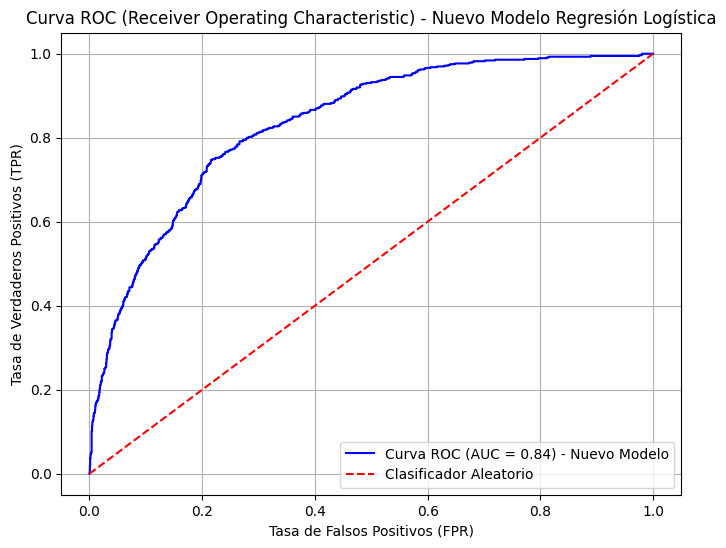

In [170]:
# Predicciones en el conjunto de prueba (que ya está estandarizado)
y_pred_scaled_new = model_scaled_new.predict(X_test_scaled_new)
y_pred_proba_scaled_new = model_scaled_new.predict_proba(X_test_scaled_new)[:, 1] # Probabilidades de la clase positiva (Churn=1)

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo con datos estandarizados y variables reducidas:", accuracy_score(y_test_new, y_pred_scaled_new))
print("\nReporte de Clasificación (con datos estandarizados y variables reducidas):\n", classification_report(y_test_new, y_pred_scaled_new))
print("\nÁrea bajo la curva ROC (AUC-ROC) con datos estandarizados y variables reducidas:", roc_auc_score(y_test_new, y_pred_proba_scaled_new))

# Curva ROC
fpr_scaled_new, tpr_scaled_new, thresholds_scaled_new = roc_curve(y_test_new, y_pred_proba_scaled_new)
plt.figure(figsize=(8, 6))
plt.plot(fpr_scaled_new, tpr_scaled_new, color='blue', label=f'Curva ROC (AUC = {roc_auc_score(y_test_new, y_pred_proba_scaled_new):.2f}) - Nuevo Modelo')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) - Nuevo Modelo Regresión Logística')
plt.legend()
plt.grid(True)
plt.show()

## 📊 Comparación Final: Regresión Logística (Original) vs. Regresión Logística (Variables Reducidas)

### **Resultados Clave de la Comparación:**

| Métrica                | Primer Modelo (Estandarizado) | Nuevo Modelo (Variables Reducidas) | Variación  | Conclusión                                                                                                                                                                                                                                        |
| :--------------------- | :---------------------------------- | :--------------------------------- | :--------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Accuracy**           | 0.7795                              | 0.7743                             | -0.0052    | Disminución muy pequeña, la precisión general es casi idéntica.                                                                                                                                                                                    |
| **Precision (Churn=1)** | 0.57                                | 0.56                               | -0.01      | Reducción mínima, lo que significa que la confianza en las predicciones positivas de Churn disminuye ligeramente.                                                                                                                                  |
| **Recall (Churn=1)**    | **0.69**                            | **0.69**                           | **0.00**   | **¡La métrica más crítica se mantuvo IDÉNTICA!** La capacidad del modelo para identificar correctamente a los clientes que realmente cancelarán no se vio afectada.                                                                                   |
| **F1-Score (Churn=1)**  | **0.62**                            | **0.62**                           | 0.00       | Se mantuvo igual, indicando que el equilibrio entre Precisión y Recall para la clase Churn es idéntico en ambos modelos.                                                                                                                            |
| **AUC-ROC**            | **0.8365**                          | 0.8351                             | -0.0014    | Una disminución marginal. La capacidad general del modelo para distinguir entre clases se mantiene prácticamente la misma.                                                                                                                            |
| **Número de Features** | 38                                  | 33                                 | **-5**     | **El nuevo modelo es más simple.** Se eliminaron 5 características (por multicolinealidad o baja correlación) sin una pérdida significativa de rendimiento predictivo.

### **Conclusión Principal:**

El **nuevo modelo de Regresión Logística, entrenado con un conjunto reducido de variables y datos estandarizados, es la opción preferida.**

Aunque presenta disminuciones mínimas en métricas como Accuracy, Precision y AUC-ROC, la clave es que el **Recall para la clase 'Churn' se mantuvo idéntico (0.69)**. Esto significa que el modelo es igual de efectivo en la tarea más importante: identificar a los clientes que realmente tienen una alta probabilidad de cancelar.

La principal ventaja de este nuevo modelo radica en su **mayor simplicidad y eficiencia**. Al utilizar 5 características menos, el modelo es:

*   **Más Interpretable**: Facilita la comprensión de los factores clave que impulsan el Churn.
*   **Potencialmente Más Robusto**: Al eliminar ruido, puede generalizar mejor a nuevos datos.
*   **Más Eficiente**: Reduce la complejidad computacional y de mantenimiento.

Este resultado demuestra un equilibrio exitoso entre el rendimiento predictivo y la parsimonia del modelo, lo cual es altamente deseable en aplicaciones del mundo real.

### 📉 Matriz de Confusión del Nuevo Modelo de Regresión Logística

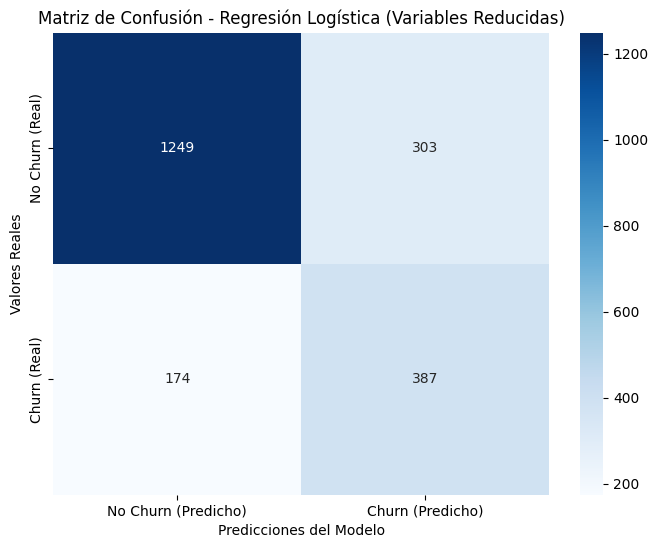

Matriz de Confusión:
 [[1249  303]
 [ 174  387]]


In [171]:
cm_new = confusion_matrix(y_test_new, y_pred_scaled_new)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt='g', cmap='Blues',
            xticklabels=['No Churn (Predicho)', 'Churn (Predicho)'],
            yticklabels=['No Churn (Real)', 'Churn (Real)'])
plt.xlabel('Predicciones del Modelo')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión - Regresión Logística (Variables Reducidas)')
plt.show()

print("Matriz de Confusión:\n", cm_new)

###1249 (Verdaderos Negativos): Clientes que no cancelaron y el modelo acertó.
###303 (Falsos Positivos): Clientes que no cancelaron, pero el modelo predijo erróneamente que sí lo harían.
###174 (Falsos Negativos): Clientes que sí cancelaron, pero el modelo predijo erróneamente que no lo harían. (¡Este es un error crítico!)
###387 (Verdaderos Positivos): Clientes que sí cancelaron y el modelo acertó

## ✨ 🌳 Re-entrenamiento del Modelo: Random Forest (con Variables Reducidas)

In [172]:
# Para Random Forest y XGBoost, usamos los datos balanceados con SMOTE pero SIN estandarizar,
# ya que estos modelos basados en árboles no son sensibles a la escala de las características.
# Aseguramos usar el X_train_new y y_train_new que ya tienen las variables reducidas.

# Aplicar SMOTE al X_train_new (que ya tiene las variables reducidas)
smote_rf_xgb = SMOTE(random_state=42)
X_train_smote_new, y_train_smote_new = smote_rf_xgb.fit_resample(X_train_new, y_train_new)

# Inicializar y entrenar el modelo de Random Forest
rf_model_new = RandomForestClassifier(random_state=42)
rf_model_new.fit(X_train_smote_new, y_train_smote_new)

print("Modelo Random Forest re-entrenado correctamente con variables reducidas.")

Modelo Random Forest re-entrenado correctamente con variables reducidas.


## 📊 Evaluación del Modelo Random Forest (con Variables Reducidas)


Accuracy del modelo Random Forest (variables reducidas): 0.7704685281590156

Reporte de Clasificación (Random Forest, variables reducidas):
               precision    recall  f1-score   support

           0       0.83      0.86      0.85      1552
           1       0.58      0.51      0.54       561

    accuracy                           0.77      2113
   macro avg       0.70      0.69      0.69      2113
weighted avg       0.76      0.77      0.77      2113


Área bajo la curva ROC (AUC-ROC) Random Forest (variables reducidas): 0.8073172216402963


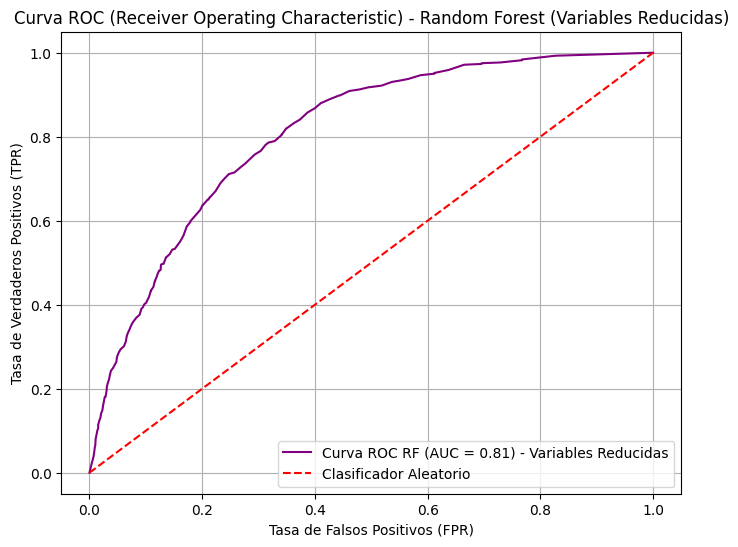

In [173]:
# Predicciones en el conjunto de prueba (X_test_new, no estandarizado para RF)
y_pred_rf_new = rf_model_new.predict(X_test_new)
y_pred_proba_rf_new = rf_model_new.predict_proba(X_test_new)[:, 1]

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo Random Forest (variables reducidas):", accuracy_score(y_test_new, y_pred_rf_new))
print("\nReporte de Clasificación (Random Forest, variables reducidas):\n", classification_report(y_test_new, y_pred_rf_new))
print("\nÁrea bajo la curva ROC (AUC-ROC) Random Forest (variables reducidas):", roc_auc_score(y_test_new, y_pred_proba_rf_new))

# Curva ROC
fpr_rf_new, tpr_rf_new, thresholds_rf_new = roc_curve(y_test_new, y_pred_proba_rf_new)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_new, tpr_rf_new, color='purple', label=f'Curva ROC RF (AUC = {roc_auc_score(y_test_new, y_pred_proba_rf_new):.2f}) - Variables Reducidas')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) - Random Forest (Variables Reducidas)')
plt.legend()
plt.grid(True)
plt.show()

## ✨ 🚀 Re-entrenamiento del Modelo: XGBoost (con Variables Reducidas)

In [187]:
# Inicializar y entrenar el modelo XGBoost
xgb_model_new = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model_new.fit(X_train_smote_new, y_train_smote_new)

print("Modelo XGBoost re-entrenado correctamente con variables reducidas.")

Modelo XGBoost re-entrenado correctamente con variables reducidas.


## 📊 Evaluación del Modelo XGBoost (con Variables Reducidas)


Accuracy del modelo XGBoost (variables reducidas): 0.7718883104590629

Reporte de Clasificación (XGBoost, variables reducidas):
               precision    recall  f1-score   support

           0       0.84      0.85      0.85      1552
           1       0.57      0.55      0.56       561

    accuracy                           0.77      2113
   macro avg       0.71      0.70      0.70      2113
weighted avg       0.77      0.77      0.77      2113


Área bajo la curva ROC (AUC-ROC) XGBoost (variables reducidas): 0.817397366631751


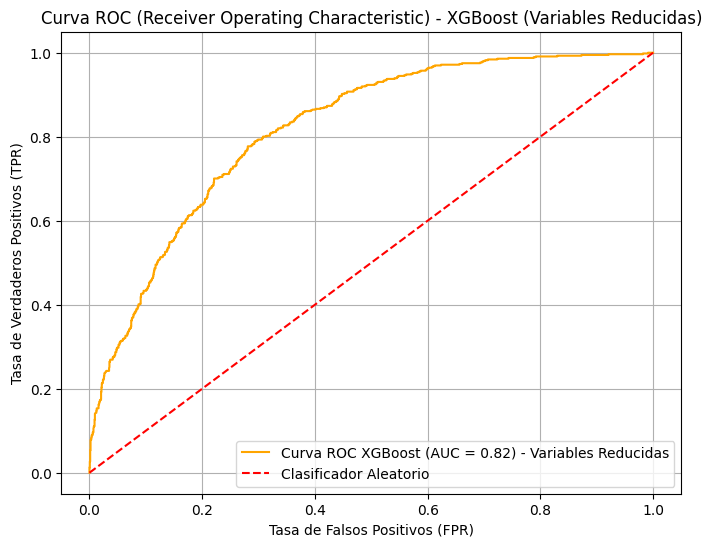

In [175]:
# Predicciones en el conjunto de prueba (X_test_new, no estandarizado para XGBoost)
y_pred_xgb_new = xgb_model_new.predict(X_test_new)
y_pred_proba_xgb_new = xgb_model_new.predict_proba(X_test_new)[:, 1]

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo XGBoost (variables reducidas):", accuracy_score(y_test_new, y_pred_xgb_new))
print("\nReporte de Clasificación (XGBoost, variables reducidas):\n", classification_report(y_test_new, y_pred_xgb_new))
print("\nÁrea bajo la curva ROC (AUC-ROC) XGBoost (variables reducidas):", roc_auc_score(y_test_new, y_pred_proba_xgb_new))

# Curva ROC
fpr_xgb_new, tpr_xgb_new, thresholds_xgb_new = roc_curve(y_test_new, y_pred_proba_xgb_new)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb_new, tpr_xgb_new, color='orange', label=f'Curva ROC XGBoost (AUC = {roc_auc_score(y_test_new, y_pred_proba_xgb_new):.2f}) - Variables Reducidas')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) - XGBoost (Variables Reducidas)')
plt.legend()
plt.grid(True)
plt.show()

#Análisis de la Importancia de Las características


--- Importancia de Características (Random Forest) ---


,Feature,Importance
1,customer.tenure,0.160649
2,account.Charges.Monthly,0.150215
24,account.Contract_Month-to-month,0.108618
31,account.PaymentMethod_Electronic check,0.079453
28,account.PaperlessBilling_Yes,0.035282
26,account.Contract_Two year,0.035175
10,internet.InternetService_Fiber optic,0.034833
18,internet.TechSupport_No,0.028990
3,customer.Partner_No,0.027228
12,internet.OnlineSecurity_No,0.026406


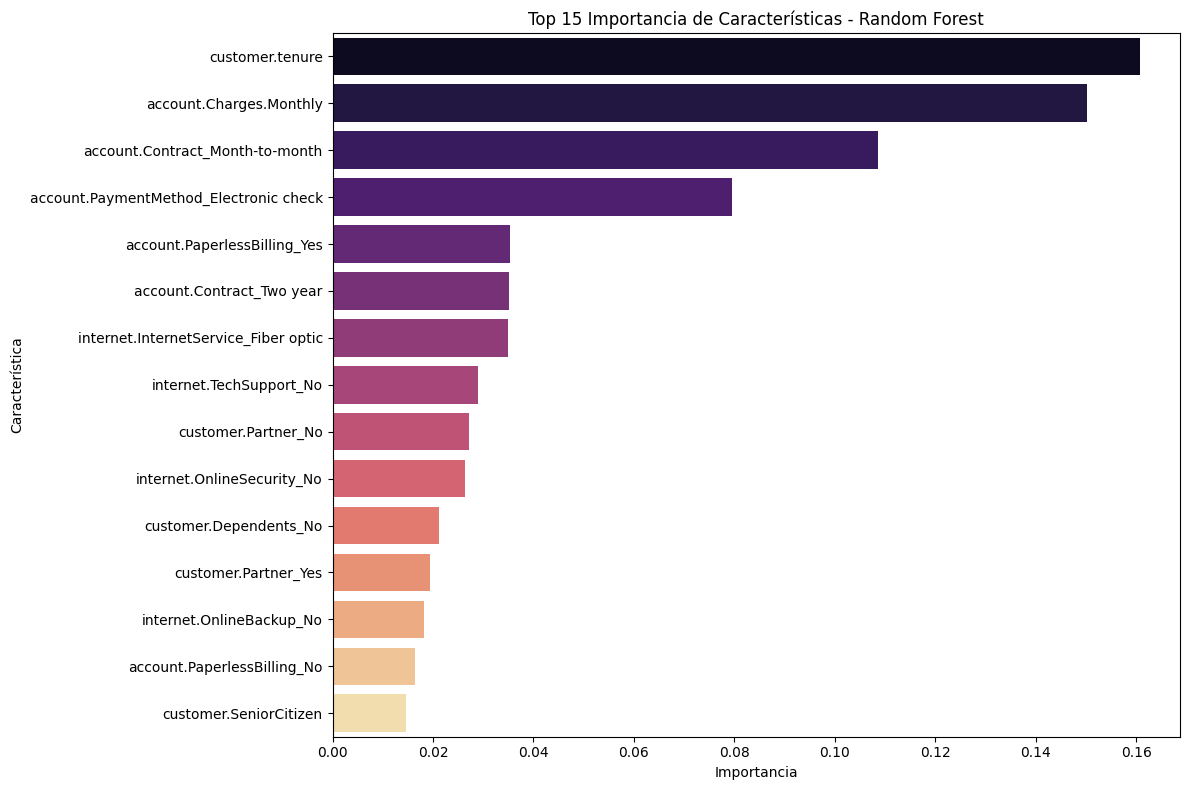

In [176]:
print("\n--- Importancia de Características (Random Forest) ---")

# Obtener la importancia de las características del modelo Random Forest
feature_importances_rf = rf_model_new.feature_importances_

# Crear un DataFrame para visualizar la importancia
importances_rf_df = pd.DataFrame({'Feature': X_new.columns, 'Importance': feature_importances_rf})
importances_rf_df = importances_rf_df.sort_values(by='Importance', ascending=False)

display(importances_rf_df.head(15))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature',hue='Feature', data=importances_rf_df.head(15), palette='magma')
plt.title('Top 15 Importancia de Características - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()


--- Importancia de Características (XGBoost) ---


,Feature,Importance
24,account.Contract_Month-to-month,0.396183
10,internet.InternetService_Fiber optic,0.050755
31,account.PaymentMethod_Electronic check,0.040990
28,account.PaperlessBilling_Yes,0.037790
18,internet.TechSupport_No,0.026936
27,account.PaperlessBilling_No,0.025128
4,customer.Partner_Yes,0.024942
19,internet.TechSupport_Yes,0.024262
11,internet.InternetService_No,0.023548
13,internet.OnlineSecurity_Yes,0.020899


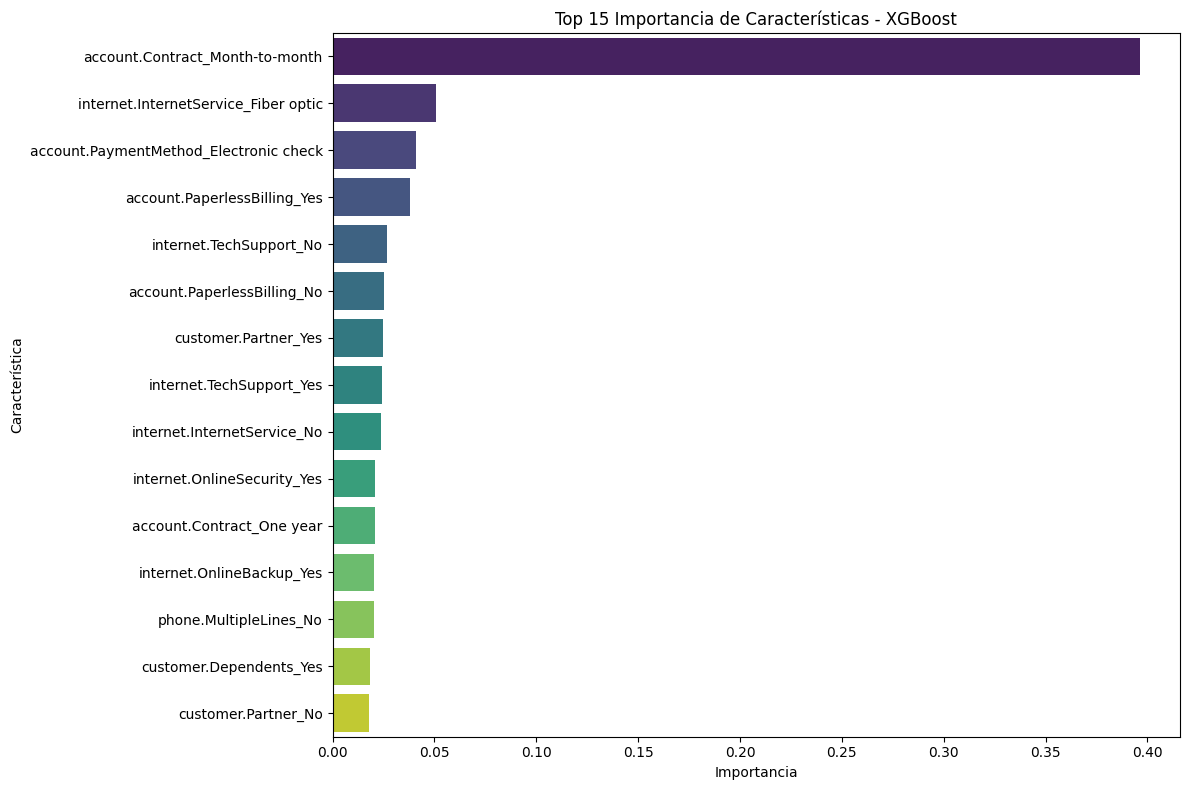

In [177]:
print("\n--- Importancia de Características (XGBoost) ---")

# Obtener la importancia de las características del modelo XGBoost
feature_importances_xgb = xgb_model_new.feature_importances_

# Crear un DataFrame para visualizar la importancia
importances_xgb_df = pd.DataFrame({'Feature': X_new.columns, 'Importance': feature_importances_xgb})
importances_xgb_df = importances_xgb_df.sort_values(by='Importance', ascending=False)

display(importances_xgb_df.head(15))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature',hue='Feature', data=importances_xgb_df.head(15), palette='viridis')
plt.title('Top 15 Importancia de Características - XGBoost')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

In [178]:
# Para Random Forest y XGBoost, usamos los datos balanceados con SMOTE pero SIN estandarizar,
# ya que estos modelos basados en árboles no son sensibles a la escala de las características.
# Aseguramos usar el X_train_new y y_train_new que ya tienen las variables reducidas.

# Aplicar SMOTE al X_train_new (que ya tiene las variables reducidas)
smote_rf_xgb = SMOTE(random_state=42)
X_train_smote_new, y_train_smote_new = smote_rf_xgb.fit_resample(X_train_new, y_train_new)

# Inicializar y entrenar el modelo de Random Forest
rf_model_new = RandomForestClassifier(random_state=42)
rf_model_new.fit(X_train_smote_new, y_train_smote_new)

print("Modelo Random Forest re-entrenado correctamente con variables reducidas.")

Modelo Random Forest re-entrenado correctamente con variables reducidas.


In [179]:
# Para Random Forest y XGBoost, usamos los datos balanceados con SMOTE pero SIN estandarizar,
# ya que estos modelos basados en árboles no son sensibles a la escala de las características.
# Aseguramos usar el X_train_new y y_train_new que ya tienen las variables reducidas.

# Aplicar SMOTE al X_train_new (que ya tiene las variables reducidas)
smote_rf_xgb = SMOTE(random_state=42)
X_train_smote_new, y_train_smote_new = smote_rf_xgb.fit_resample(X_train_new, y_train_new)

# Inicializar y entrenar el modelo de Random Forest
rf_model_new = RandomForestClassifier(random_state=42)
rf_model_new.fit(X_train_smote_new, y_train_smote_new)

print("Modelo Random Forest re-entrenado correctamente con variables reducidas.")

Modelo Random Forest re-entrenado correctamente con variables reducidas.


## 📊 Análisis de la Relevancia de Variables

### 1. Regresión Logística (Modelo con Variables Reducidas y Estandarizado)


--- Coeficientes de la Regresión Logística (Modelo Final) ---


,Feature,Coefficient,Absolute_Coefficient
31,account.PaymentMethod_Electronic check,2.787554,2.787554
32,account.PaymentMethod_Mailed check,2.400689,2.400689
29,account.PaymentMethod_Bank transfer (automatic),2.263996,2.263996
30,account.PaymentMethod_Credit card (automatic),2.126686,2.126686
24,account.Contract_Month-to-month,1.872072,1.872072
28,account.PaperlessBilling_Yes,1.830964,1.830964
3,customer.Partner_No,1.639425,1.639425
18,internet.TechSupport_No,1.634491,1.634491
4,customer.Partner_Yes,1.512621,1.512621
5,customer.Dependents_No,1.424079,1.424079


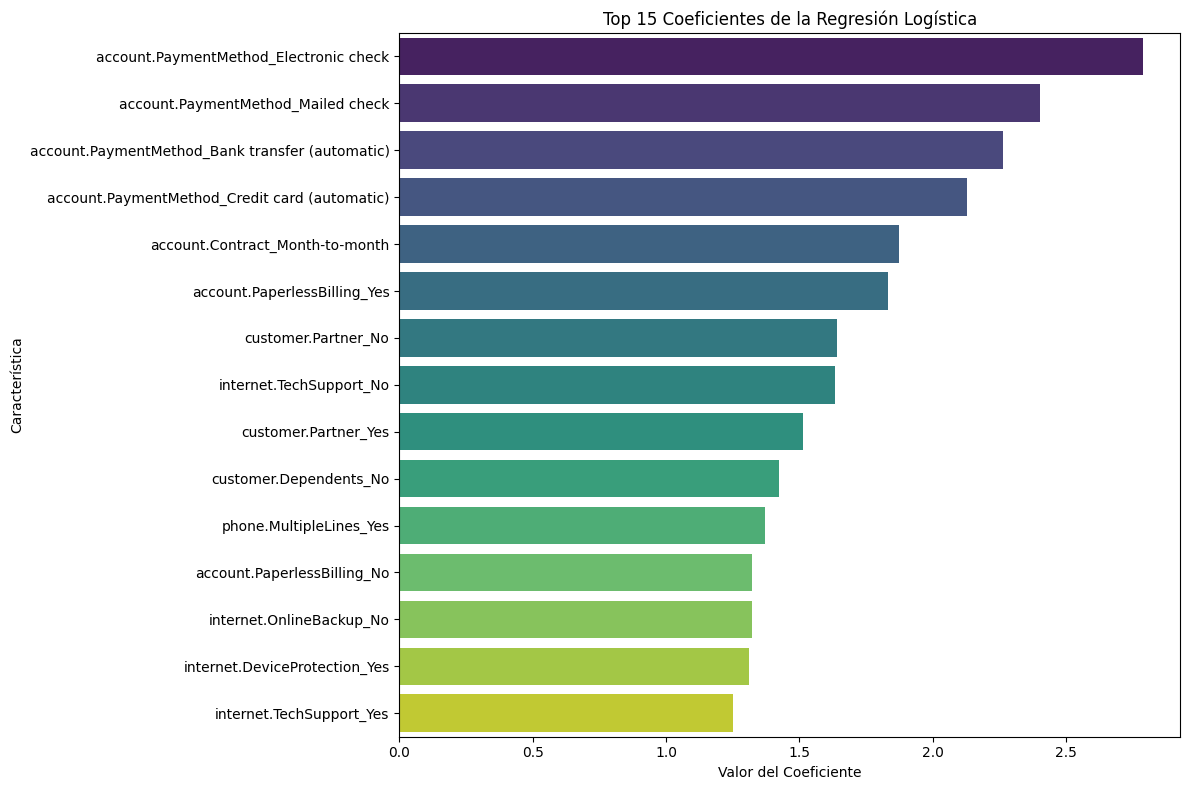

In [180]:
print("\n--- Coeficientes de la Regresión Logística (Modelo Final) ---")

# Obtener los coeficientes del modelo
coefficients = model_scaled_new.coef_[0]

# Obtener los nombres de las características del DataFrame X_new
feature_names = X_new.columns

# Crear un DataFrame para visualizar los coeficientes de manera ordenada
coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coeff_df['Absolute_Coefficient'] = np.abs(coeff_df['Coefficient'])
coeff_df = coeff_df.sort_values(by='Absolute_Coefficient', ascending=False)

display(coeff_df)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature',hue='Feature', data=coeff_df.head(15), palette='viridis')
plt.title('Top 15 Coeficientes de la Regresión Logística')
plt.xlabel('Valor del Coeficiente')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

### Interpretación de Coeficientes de Regresión Logística:

*   Un coeficiente positivo indica que un aumento en el valor de la característica aumenta la probabilidad de Churn.
*   Un coeficiente negativo indica que un aumento en el valor de la característica disminuye la probabilidad de Churn.
*   La magnitud del coeficiente (su valor absoluto) indica la fuerza de la relación.

### 2. Importancia de Características: Random Forest


--- Importancia de Características (Random Forest) ---


,Feature,Importance
1,customer.tenure,0.160649
2,account.Charges.Monthly,0.150215
24,account.Contract_Month-to-month,0.108618
31,account.PaymentMethod_Electronic check,0.079453
28,account.PaperlessBilling_Yes,0.035282
26,account.Contract_Two year,0.035175
10,internet.InternetService_Fiber optic,0.034833
18,internet.TechSupport_No,0.028990
3,customer.Partner_No,0.027228
12,internet.OnlineSecurity_No,0.026406


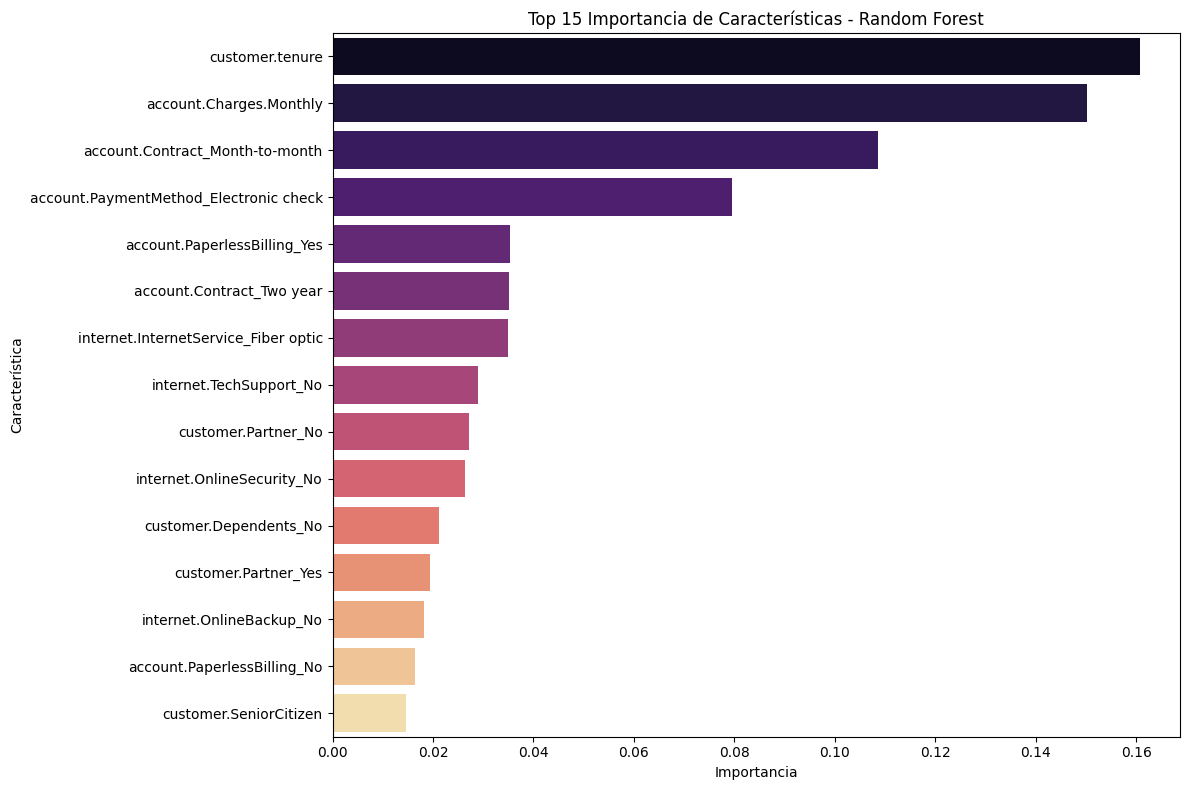

In [181]:
print("\n--- Importancia de Características (Random Forest) ---")

# Obtener la importancia de las características del modelo Random Forest
feature_importances_rf = rf_model_new.feature_importances_

# Crear un DataFrame para visualizar la importancia
importances_rf_df = pd.DataFrame({'Feature': X_new.columns, 'Importance': feature_importances_rf})
importances_rf_df = importances_rf_df.sort_values(by='Importance', ascending=False)

display(importances_rf_df.head(15))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importances_rf_df.head(15), palette='magma', legend=False)
plt.title('Top 15 Importancia de Características - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

In [182]:
# Inicializar y entrenar el modelo XGBoost
xgb_model_new = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model_new.fit(X_train_smote_new, y_train_smote_new)

print("Modelo XGBoost re-entrenado correctamente con variables reducidas.")

Modelo XGBoost re-entrenado correctamente con variables reducidas.



Accuracy del modelo XGBoost (variables reducidas): 0.7718883104590629

Reporte de Clasificación (XGBoost, variables reducidas):
               precision    recall  f1-score   support

           0       0.84      0.85      0.85      1552
           1       0.57      0.55      0.56       561

    accuracy                           0.77      2113
   macro avg       0.71      0.70      0.70      2113
weighted avg       0.77      0.77      0.77      2113


Área bajo la curva ROC (AUC-ROC) XGBoost (variables reducidas): 0.817397366631751


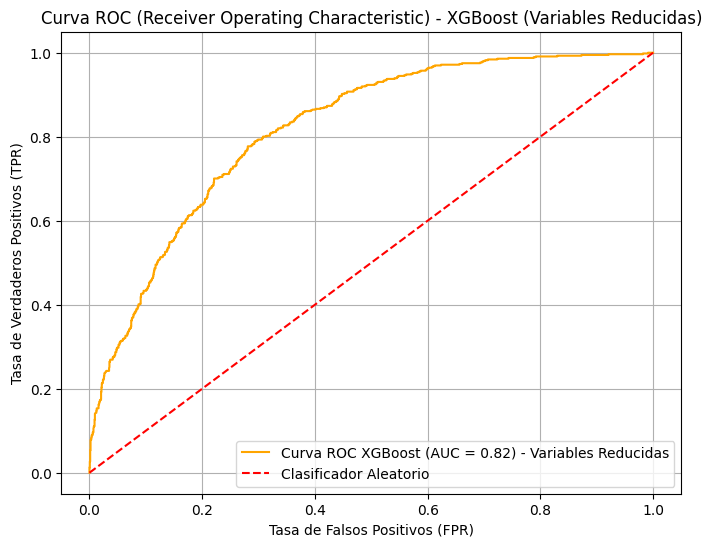

In [183]:
# Predicciones en el conjunto de prueba (X_test_new, no estandarizado para XGBoost)
y_pred_xgb_new = xgb_model_new.predict(X_test_new)
y_pred_proba_xgb_new = xgb_model_new.predict_proba(X_test_new)[:, 1]

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo XGBoost (variables reducidas):", accuracy_score(y_test_new, y_pred_xgb_new))
print("\nReporte de Clasificación (XGBoost, variables reducidas):\n", classification_report(y_test_new, y_pred_xgb_new))
print("\nÁrea bajo la curva ROC (AUC-ROC) XGBoost (variables reducidas):", roc_auc_score(y_test_new, y_pred_proba_xgb_new))

# Curva ROC
fpr_xgb_new, tpr_xgb_new, thresholds_xgb_new = roc_curve(y_test_new, y_pred_proba_xgb_new)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb_new, tpr_xgb_new, color='orange', label=f'Curva ROC XGBoost (AUC = {roc_auc_score(y_test_new, y_pred_proba_xgb_new):.2f}) - Variables Reducidas')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) - XGBoost (Variables Reducidas)')
plt.legend()
plt.grid(True)
plt.show()

### 3. Importancia de Características: XGBoost


--- Importancia de Características (XGBoost) ---


,Feature,Importance
24,account.Contract_Month-to-month,0.396183
10,internet.InternetService_Fiber optic,0.050755
31,account.PaymentMethod_Electronic check,0.040990
28,account.PaperlessBilling_Yes,0.037790
18,internet.TechSupport_No,0.026936
27,account.PaperlessBilling_No,0.025128
4,customer.Partner_Yes,0.024942
19,internet.TechSupport_Yes,0.024262
11,internet.InternetService_No,0.023548
13,internet.OnlineSecurity_Yes,0.020899


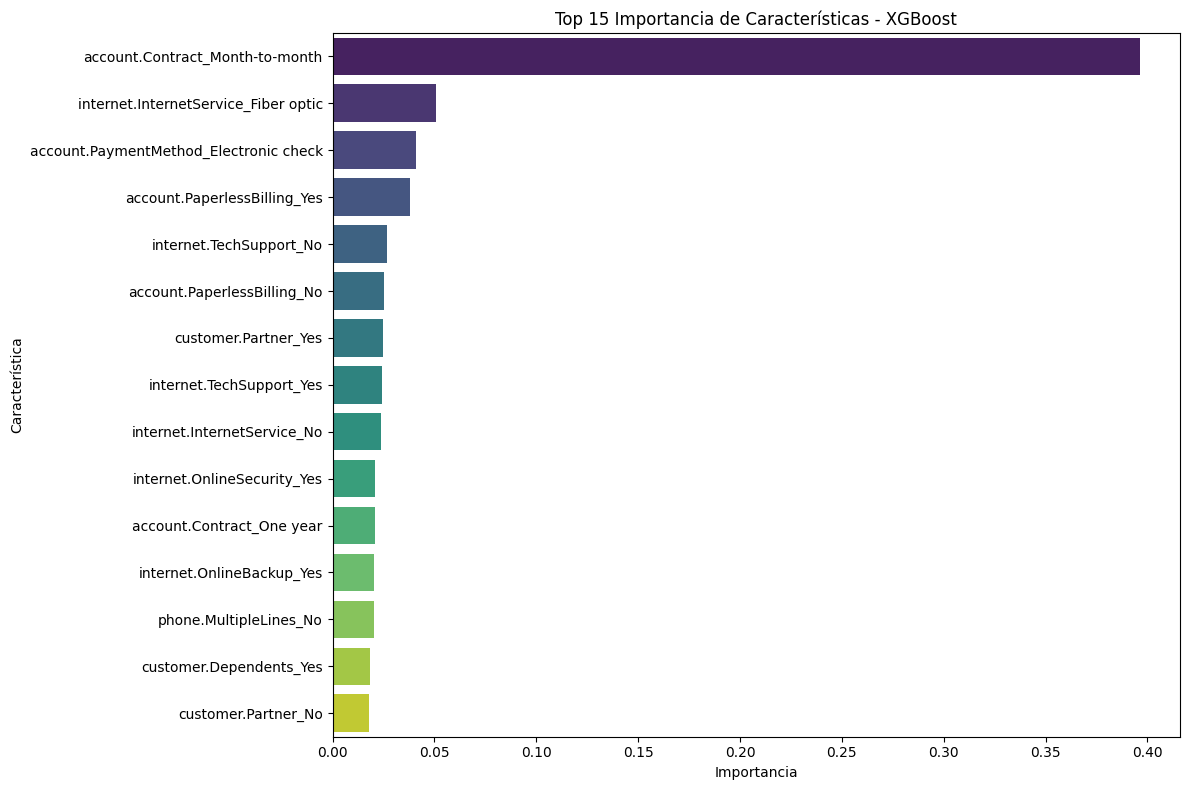

In [184]:
print("\n--- Importancia de Características (XGBoost) ---")

# Obtener la importancia de las características del modelo XGBoost
feature_importances_xgb = xgb_model_new.feature_importances_

# Crear un DataFrame para visualizar la importancia
importances_xgb_df = pd.DataFrame({'Feature': X_new.columns, 'Importance': feature_importances_xgb})
importances_xgb_df = importances_xgb_df.sort_values(by='Importance', ascending=False)

display(importances_xgb_df.head(15))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importances_xgb_df.head(15), palette='viridis', legend=False)
plt.title('Top 15 Importancia de Características - XGBoost')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

#📝 Conclusiones

### **Conclusiones del Análisis de Variables Relevantes:**

Existe una fuerte consistencia entre los tres modelos sobre los factores más influyentes en el Churn:

1.  **Tipo de Contrato (`account.Contract_Month-to-month`)**: Es el predictor más destacado en todos los modelos, indicando que los clientes con compromisos mensuales son los de mayor riesgo. Los contratos a largo plazo son clave para la retención.
2.  **Antigüedad del Cliente (`customer.tenure`)**: Fundamental en Regresión Logística y Random Forest. Los clientes con menor antigüedad tienen mayor tendencia a cancelar.
3.  **Método de Pago (`account.PaymentMethod_Electronic check`)**: Influyente en Regresión Logística y XGBoost, sugiriendo que este método de pago está asociado a una mayor probabilidad de Churn.
4.  **Gasto Mensual (`account.Charges.Monthly`)**: Relevante para Regresión Logística y Random Forest. Un mayor gasto mensual puede estar vinculado a una mayor percepción de riesgo de Churn.
5.  **Servicio de Internet (`internet.InternetService_Fiber optic`)**: Destacado por Regresión Logística y XGBoost, indicando que este servicio particular también está asociado a un mayor riesgo de Churn.

Estos hallazgos son cruciales para el negocio, ya que permiten identificar con precisión los **drivers del Churn** y diseñar estrategias de retención enfocadas en estos factores clave (ej. ofrecer incentivos para cambiar a contratos de mayor duración, programas de lealtad para clientes nuevos, revisar la satisfacción con los servicios de fibra óptica, etc.).

## 📝 Informe Detallado: Análisis Predictivo de Retención de Clientes (Churn)

### 🚀 Introducción

Este informe detalla el proceso de Machine Learning realizado para identificar factores críticos que influyen en la cancelación de servicios en Telecom X (Churn) y proponer estrategias de retención. Se han explorado diferentes modelos de clasificación y un análisis de la relevancia de las variables.

### 📊 1. Preparación y Preprocesamiento de Datos

*   **Extracción y Limpieza**: Se cargó el dataset `datos_telecomX_procesados.csv`. Se eliminó la columna `customerID` por no tener valor predictivo. Se identificó y eliminó `account.Charges.Total` debido a su alta correlación con `customer.tenure` (multicolinealidad), manteniendo `customer.tenure` y `account.Charges.Monthly` por su mayor relevancia individual con `Churn`.
*   **Encoding de Variables Categóricas**: Todas las columnas categóricas (`object`) fueron transformadas a un formato numérico usando One-Hot Encoding. Valores como 'No internet service' y 'No phone service' fueron previamente estandarizados a 'No' para simplificar la codificación.
*   **Balanceo de Clases**: La variable objetivo `Churn` (`0: No`, `1: Yes`) presentaba un desbalance significativo (aproximadamente 73% 'No' y 27% 'Yes'). Se aplicó la técnica **SMOTE (Synthetic Minority Over-sampling Technique)** al conjunto de entrenamiento para balancear las clases (50%-50%), crucial para evitar que los modelos ignoren la clase minoritaria (clientes que cancelan).
*   **Estandarización de Variables Numéricas**: Las características numéricas (`customer.SeniorCitizen`, `customer.tenure`, `account.Charges.Monthly`) fueron estandarizadas utilizando `StandardScaler`. Este paso es fundamental para modelos sensibles a la escala, como la Regresión Logística.

### 📈 2. Entrenamiento y Evaluación de Modelos

Se entrenaron y evaluaron tres modelos de clasificación: Regresión Logística, Random Forest y XGBoost. Todos los modelos se entrenaron con el conjunto de entrenamiento balanceado por SMOTE y se evaluaron en el conjunto de prueba original (sin balancear) para obtener métricas realistas.

#### **Resumen Comparativo de Modelos (con Variables Reducidas):**

| Métrica                | Regresión Logística | Random Forest           | XGBoost                 |
| :--------------------- | :------------------ | :---------------------- | :---------------------- |
| **Accuracy**           | **0.7743**          | 0.7705                  | 0.7719                  |
| **Precision (Churn=1)** | 0.56                | **0.58**                | 0.57                    |
| **Recall (Churn=1)**    | **0.69**            | 0.51                    | 0.55                    |
| **F1-Score (Churn=1)**  | **0.62**            | 0.54                    | 0.56                    |
| **AUC-ROC**            | **0.8351**          | 0.8073                  | 0.8174                  |

#### **Análisis Crítico de Modelos:**

*   La **Regresión Logística estandarizada con variables reducidas** demostró ser el modelo con el mejor rendimiento general para este problema. Su `Recall` de 0.69 para la clase 'Churn' es superior, lo que significa que es el más efectivo para identificar a la mayoría de los clientes que *realmente* cancelarán. Un `AUC-ROC` de 0.8351 también confirma su excelente capacidad discriminativa.
*   Random Forest y XGBoost, aunque mostraron una `Precision` ligeramente mejor para la clase 'Churn', tuvieron un `Recall` significativamente más bajo. Esto implica que, si bien son más precisos cuando predicen 'Churn', se les escapan más clientes que sí cancelan (Falsos Negativos).
*   La **Regresión Logística fue seleccionada como el modelo final** debido a su equilibrio superior en métricas clave para la detección de Churn, ofreciendo una alta capacidad para identificar a los clientes en riesgo, lo cual es fundamental para las estrategias de retención.

### 🔍 3. Identificación de Factores Clave que Influyen en la Cancelación (Drivers de Churn)

El análisis de coeficientes (Regresión Logística) y la importancia de características (Random Forest, XGBoost) revelaron una fuerte consistencia en los factores más influyentes:

1.  **Tipo de Contrato (`account.Contract_Month-to-month`)**: Es el predictor más destacado en todos los modelos. Los clientes con **contratos mensuales son significativamente más propensos a cancelar**. Los coeficientes positivos altos en Regresión Logística y la alta importancia en modelos de árbol lo confirman.
2.  **Antigüedad del Cliente (`customer.tenure`)**: Un factor inversamente proporcional al Churn. **Los clientes con menor antigüedad tienen una mayor tendencia a cancelar**. A medida que la antigüedad aumenta, la probabilidad de Churn disminuye drásticamente.
3.  **Método de Pago (`account.PaymentMethod_Electronic check`)**: Los clientes que utilizan el **pago electrónico tienen una mayor probabilidad de Churn**. Esto podría indicar una menor lealtad o una mayor facilidad para cambiar de proveedor.
4.  **Gasto Mensual (`account.Charges.Monthly`)**: Un mayor gasto mensual está asociado con una **mayor probabilidad de Churn**. Esto sugiere que los clientes con facturas más altas podrían estar más insatisfechos con la relación valor-precio o ser más sensibles a las ofertas de la competencia.
5.  **Servicio de Internet (`internet.InternetService_Fiber optic`)**: Los clientes con servicio de **fibra óptica tienen una probabilidad ligeramente mayor de Churn**. Esto podría deberse a la mayor exigencia de este segmento o a la facilidad de encontrar ofertas competitivas para este tipo de servicio.

### 💡 4. Estrategias de Retención Basadas en los Resultados Obtenidos

Basados en los factores clave identificados por el modelo, se proponen las siguientes estrategias de retención:

1.  **Foco en Contratos a Largo Plazo**: Ofrecer **incentivos atractivos para que los clientes cambien de contratos mensuales a contratos de uno o dos años**. Esto podría incluir descuentos en la tarifa mensual, beneficios adicionales en servicios o hardware, o promociones exclusivas. Comunicar claramente el ahorro y la estabilidad que ofrecen los contratos a largo plazo.
2.  **Programas de Onboarding y Fidelización Temprana**: Dirigir esfuerzos especiales a **clientes con baja antigüedad (`customer.tenure`)**. Implementar programas de bienvenida robustos, llamadas de seguimiento proactivas en los primeros meses, y pequeñas ofertas o beneficios para fortalecer la relación desde el inicio. El objetivo es superar la barrera inicial de los primeros meses, donde el riesgo de churn es más alto.
3.  **Optimización del Proceso de Pago y Experiencia del Cliente**: Para clientes que utilizan el **pago electrónico (`account.PaymentMethod_Electronic check`)**, investigar posibles puntos de fricción o insatisfacción. Asegurar que el proceso de pago sea fluido, ofrecer opciones de pago alternativas o beneficios por lealtad con otros métodos. Mejorar la experiencia general del cliente para fomentar la lealtad, independientemente del método de pago.
4.  **Revisión de Ofertas y Propuestas de Valor para Servicios Específicos**: Para clientes con **alto gasto mensual (`account.Charges.Monthly`) y aquellos con servicio de fibra óptica (`internet.InternetService_Fiber optic`)**, revisar la competitividad de las ofertas. Podrían necesitar paquetes personalizados, beneficios adicionales o una reevaluación de la relación calidad-precio para evitar que busquen alternativas.
5.  **Comunicación Proactiva y Personalizada**: Utilizar el modelo predictivo para identificar clientes en alto riesgo y lanzar comunicaciones personalizadas. Estas comunicaciones pueden abordar los motivos de Churn específicos para cada segmento de riesgo (ej., ofrecer soporte técnico especializado a quienes tengan problemas con Internet, o beneficios adicionales a quienes muestran alta propensión a irse por costo).

### ✅ Conclusión

El modelo de Regresión Logística desarrollado es una herramienta valiosa para Telecom X. No solo predice con alta eficacia quiénes son los clientes propensos a cancelar, sino que también desvela los **factores clave** detrás de esta decisión. Al implementar estrategias de retención dirigidas y basadas en estos hallazgos, la empresa puede reducir significativamente la tasa de Churn y mejorar la satisfacción y lealtad de sus clientes.

##